# 🎵 Spotify Music Data Analysis (1921–2020)

## Project Overview
This project analyzes a dataset of **~170,000 Spotify tracks** spanning 100 years (1921–2020).  
The goal is to uncover patterns in music trends, understand what makes a song popular, and build machine learning models to predict song popularity.

## Business Questions We Will Answer
1. How have music characteristics (energy, danceability, acousticness) changed over the decades?
2. Which features are most correlated with song popularity?
3. Who are the most represented artists in the dataset?
4. Can we predict a song's popularity using its audio features?
5. Which ML model performs best for this prediction task?

## Dataset
- **Source:** Spotify via Kaggle
- **Size:** ~170,000 tracks
- **Features:** valence, energy, danceability, acousticness, tempo, loudness, popularity, and more
- **File:** `data.csv` (place in the same folder as this notebook)

## Step 1: Import Libraries
We import all required libraries upfront. `pandas` and `numpy` handle data manipulation, `matplotlib` and `seaborn` handle visualizations, and `sklearn` is used for machine learning.

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset
We load `data.csv` from the current directory. Make sure the CSV file is placed in the **same folder** as this notebook before running.

In [7]:
df = pd.read_csv('data.csv')
print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset loaded successfully!
Shape: 170653 rows x 19 columns


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


## Step 3: Initial Data Exploration
Before cleaning, we first understand what we are working with — data types, missing values, and duplicates.  
This step helps us know **what problems exist** before fixing them.

In [8]:
print('=== Dataset Info ===')
df.info()
print()
print(f'Duplicate rows: {df.duplicated().sum()}')
print()
print('=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16 

In [9]:
print('=== Basic Statistics ===')
df.describe()

=== Basic Statistics ===


,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
count,170653.000000,170653.000000,170653.000000,170653.000000,1.706530e+05,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000
mean,0.528587,1976.787241,0.502115,0.537396,2.309483e+05,0.482389,0.084575,0.167010,5.199844,0.205839,-11.467990,0.706902,31.431794,0.098393,116.861590
std,0.263171,25.917853,0.376032,0.176138,1.261184e+05,0.267646,0.278249,0.313475,3.515094,0.174805,5.697943,0.455184,21.826615,0.162740,30.708533
min,0.000000,1921.000000,0.000000,0.000000,5.108000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000
25%,0.317000,1956.000000,0.102000,0.415000,1.698270e+05,0.255000,0.000000,0.000000,2.000000,0.098800,-14.615000,0.000000,11.000000,0.034900,93.421000
50%,0.540000,1977.000000,0.516000,0.548000,2.074670e+05,0.471000,0.000000,0.000216,5.000000,0.136000,-10.580000,1.000000,33.000000,0.045000,114.729000
75%,0.747000,1999.000000,0.893000,0.668000,2.624000e+05,0.703000,0.000000,0.102000,8.000000,0.261000,-7.183000,1.000000,48.000000,0.075600,135.537000
max,1.000000,2020.000000,0.996000,0.988000,5.403500e+06,1.000000,1.000000,1.000000,11.000000,1.000000,3.855000,1.000000,100.000000,0.970000,243.507000


**Observations:**
- The dataset has 19 columns covering audio features and metadata
- There are some duplicate rows and missing values to fix
- `release_date` needs to be converted to datetime format
- Popularity scores range from 0 to 100

## Step 4: Data Cleaning
We perform the following steps:
1. **Remove duplicates** — identical rows don't add value
2. **Fix missing values** — fill numeric columns with median (robust to outliers), text columns with 'Unknown'
3. **Convert date column** — `release_date` should be datetime format for time-series analysis
4. **Drop irrelevant columns** — `id`, `key`, `liveness`, `speechiness`, `instrumentalness` don't answer our questions

In [10]:
# 1. Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} duplicate rows')

# 2. Fill missing values
df = df.fillna(df.median(numeric_only=True))
df = df.fillna('Unknown')
print(f'Missing values after cleaning: {df.isnull().sum().sum()}')

# 3. Convert release_date to datetime and extract year
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['release_date'] = pd.to_datetime(df['release_date'], format='%d-%m-%Y', errors='coerce')
df['year'] = df['release_date'].dt.year.fillna(df['year'])

# 4. Drop columns not useful for our analysis
cols_to_drop = ['instrumentalness', 'liveness', 'speechiness', 'id', 'key']
#df.drop(columns=cols_to_drop, inplace=True)

print(f'Cleaned dataset shape: {df.shape}')

Removed 0 duplicate rows
Missing values after cleaning: 0
Cleaned dataset shape: (170653, 19)


## Step 5: Feature Distributions
### What does the data look like?
We visualize the distribution of key audio features. A **KDE (Kernel Density Estimate)** curve is overlaid to show the overall shape of each distribution.

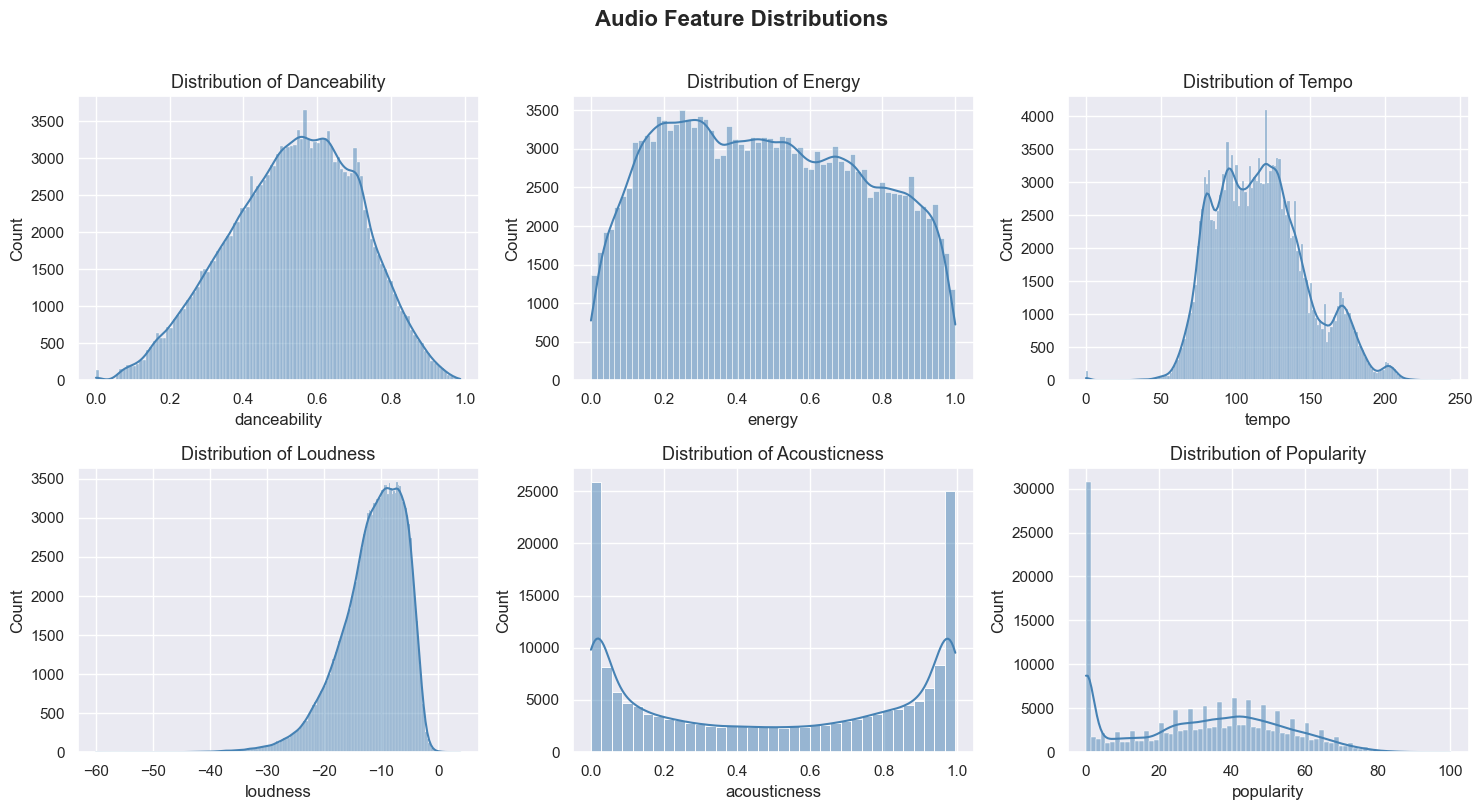

In [11]:
features = ['danceability', 'energy', 'tempo', 'loudness', 'acousticness', 'popularity']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {feature.capitalize()}', fontsize=13)
    axes[i].set_xlabel(feature)

plt.suptitle('Audio Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Key Findings:**
- **Danceability** is roughly normal around ~0.5 — most songs have moderate danceability
- **Acousticness** is heavily right-skewed — most songs in the dataset are NOT acoustic
- **Popularity** is right-skewed — most songs have low popularity, only a few are very popular (this is realistic)
- **Energy** peaks around 0.6–0.8, suggesting most songs have moderately high energy

## Step 6: Correlation Analysis
### Which features are most related to each other and to popularity?
A **correlation heatmap** shows the relationship between all numeric features.  
Values close to +1 = strong positive correlation. Values close to -1 = strong negative correlation.

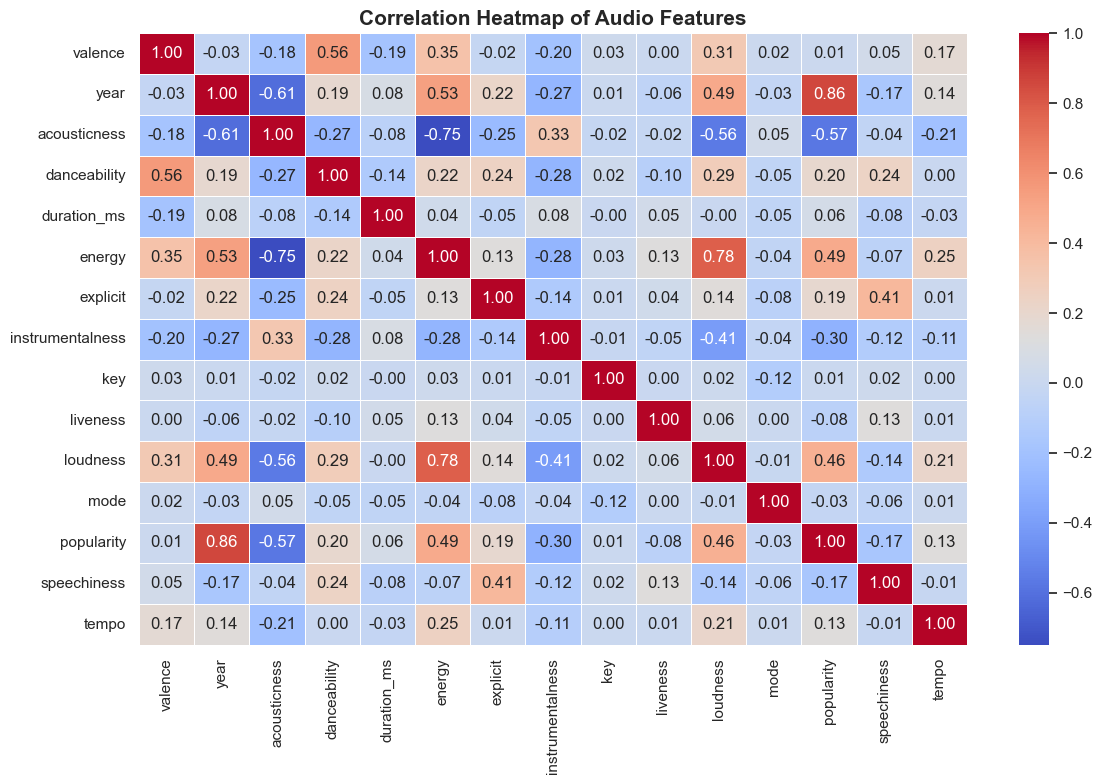

In [12]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Audio Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Top features correlated with popularity
popularity_corr = corr['popularity'].drop('popularity').sort_values(ascending=False)
print('Features most correlated with Popularity (sorted):')
print(popularity_corr.to_string())

Features most correlated with Popularity (sorted):
year                0.862442
energy              0.485005
loudness            0.457051
danceability        0.199606
explicit            0.191543
tempo               0.133310
duration_ms         0.059597
valence             0.014200
key                 0.007826
mode               -0.028897
liveness           -0.076464
speechiness        -0.171979
instrumentalness   -0.296750
acousticness       -0.573162


**Key Findings:**
- **Energy and loudness** are strongly positively correlated — louder songs tend to be more energetic
- **Acousticness and energy** are strongly negatively correlated — acoustic songs have lower energy
- **Popularity** has weak correlation with individual features — this tells us popularity is complex and depends on a combination of factors, which is why we need ML models
- **Year** has a positive correlation with popularity — recent songs tend to score higher

## Step 7: Music Trends Over Time
### How has music evolved over the decades?
We group songs by year and track how key features have changed from 1950 to 2020.

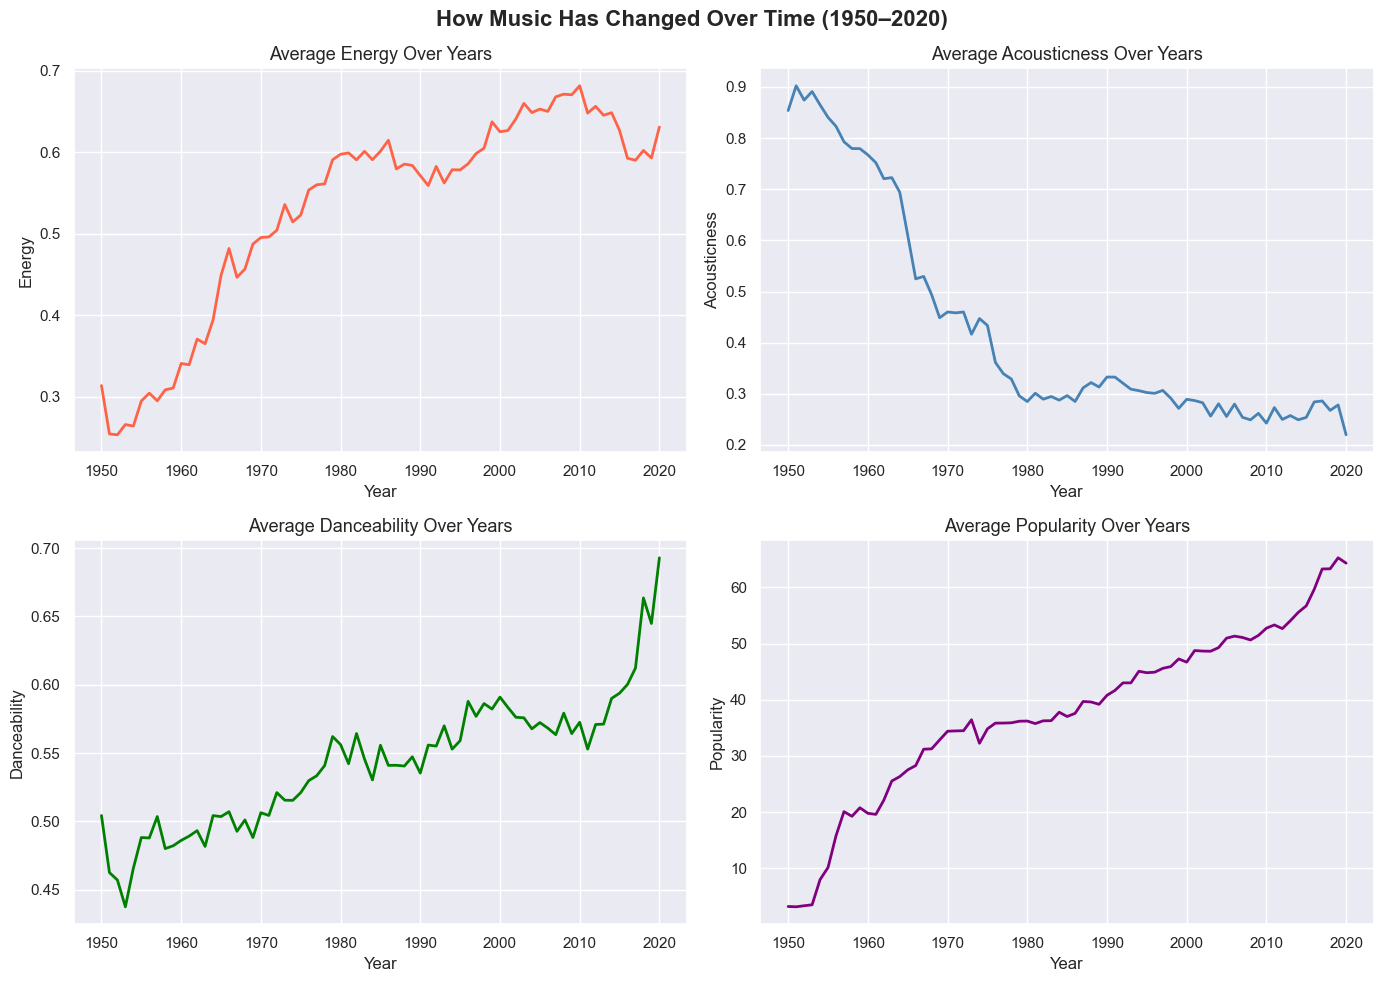

In [14]:
yearly = df.groupby('year')[['energy', 'acousticness', 'danceability', 'popularity']].mean().reset_index()
yearly = yearly[(yearly['year'] >= 1950) & (yearly['year'] <= 2020)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_info = [
    ('energy', 'tomato', 'Average Energy Over Years'),
    ('acousticness', 'steelblue', 'Average Acousticness Over Years'),
    ('danceability', 'green', 'Average Danceability Over Years'),
    ('popularity', 'purple', 'Average Popularity Over Years')
]

for ax, (col, color, title) in zip(axes.flatten(), plot_info):
    ax.plot(yearly['year'], yearly[col], color=color, linewidth=2)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Year')
    ax.set_ylabel(col.capitalize())

plt.suptitle('How Music Has Changed Over Time (1950–2020)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Findings:**
- **Energy** has steadily increased — modern music is louder and more intense than music from the 1950s
- **Acousticness** has dropped dramatically — the shift from acoustic instruments to electronic production is clearly visible
- **Danceability** has gradually increased — pop and hip-hop have pushed music toward more danceable beats
- **Popularity** is highest for recent songs — Spotify's algorithm naturally favors current music

## Step 8: Artist Analysis
### Which artists appear the most in this dataset?

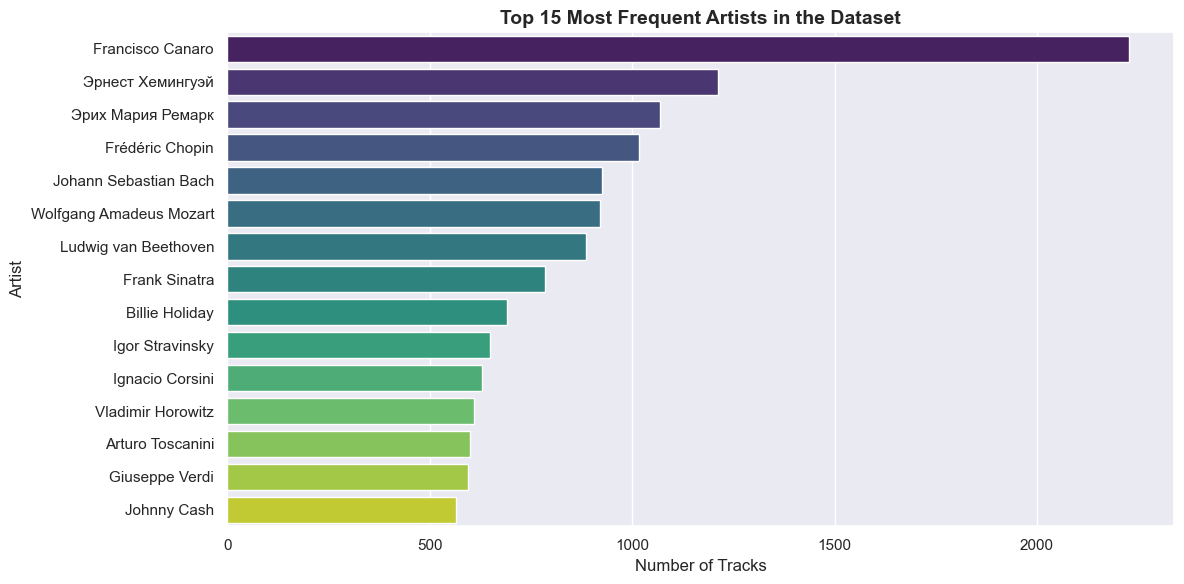

In [15]:
df_artists = df.copy()
df_artists['artists'] = df_artists['artists'].astype(str).str.strip('[]').str.replace("'", '').str.split(', ')
df_exp = df_artists.explode('artists')
df_exp['artists'] = df_exp['artists'].str.strip()

top_artists = df_exp['artists'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')
plt.title('Top 15 Most Frequent Artists in the Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tracks')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

## Step 9: Top 10 Most Popular Tracks

In [16]:
top_tracks = df.sort_values('popularity', ascending=False).head(10)[['name', 'artists', 'popularity', 'year']]
top_tracks = top_tracks.reset_index(drop=True)
top_tracks.index += 1
print('Top 10 Most Popular Tracks:')
top_tracks

Top 10 Most Popular Tracks:


,name,artists,popularity,year
1,Dakiti,"['Bad Bunny', 'Jhay Cortez']",100,2020.0
2,Mood (feat. iann dior),"['24kGoldn', 'iann dior']",99,2020.0
3,Dynamite,['BTS'],97,2020.0
4,WAP (feat. Megan Thee Stallion),"['Cardi B', 'Megan Thee Stallion']",96,2020.0
5,positions,['Ariana Grande'],96,2020.0
6,What You Know Bout Love,['Pop Smoke'],96,2020.0
7,Blinding Lights,['The Weeknd'],96,2020.0
8,For The Night (feat. Lil Baby & DaBaby),"['Pop Smoke', 'Lil Baby', 'DaBaby']",95,2020.0
9,Holy (feat. Chance The Rapper),"['Justin Bieber', 'Chance the Rapper']",95,2020.0
10,Lonely (with benny blanco),"['Justin Bieber', 'benny blanco']",95,2020.0


## Step 10: Scatter Plots — Feature Relationships
### Do energy and danceability have any visual relationship with popularity?

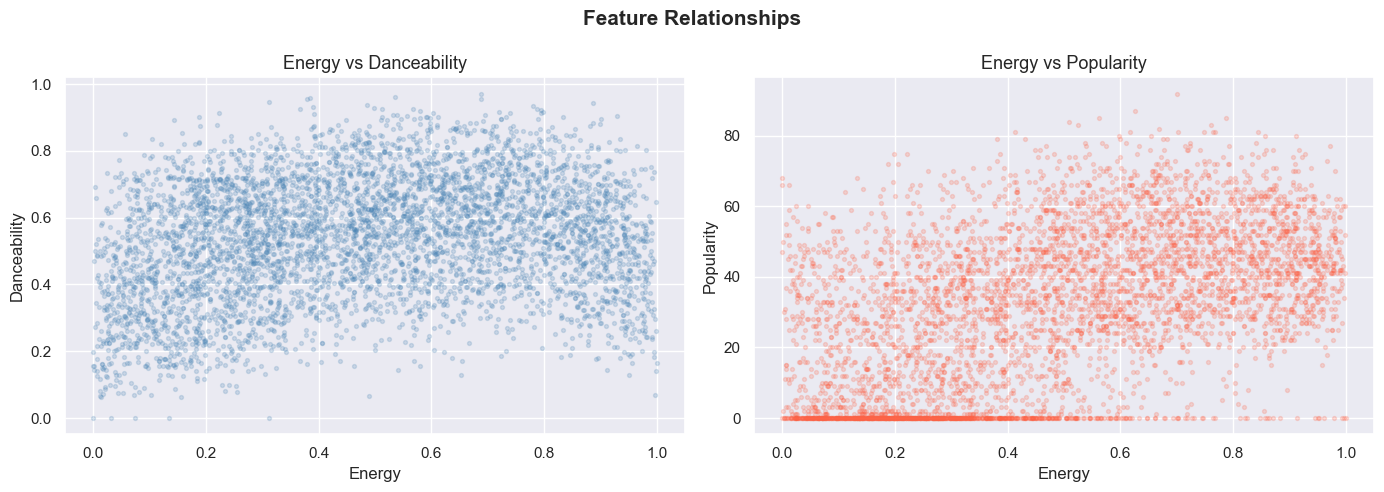

In [17]:
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['energy'], sample['danceability'], alpha=0.2, color='steelblue', s=8)
axes[0].set_title('Energy vs Danceability', fontsize=13)
axes[0].set_xlabel('Energy')
axes[0].set_ylabel('Danceability')

axes[1].scatter(sample['energy'], sample['popularity'], alpha=0.2, color='tomato', s=8)
axes[1].set_title('Energy vs Popularity', fontsize=13)
axes[1].set_xlabel('Energy')
axes[1].set_ylabel('Popularity')

plt.suptitle('Feature Relationships', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** There is no clear straight-line relationship between energy and popularity — the data is scattered. This confirms popularity is **non-linear and complex**, which motivates using more powerful ML models.

---
## Step 11: Machine Learning — Predicting Song Popularity

### Goal
Can we predict a song's popularity score using its audio features?  
We will compare four models:
1. **Linear Regression** — simple baseline model
2. **Decision Tree** — captures non-linear patterns
3. **Random Forest** — ensemble of many decision trees (reduces overfitting)
4. **Tuned Decision Tree** — Decision Tree with best parameters found by GridSearchCV

### Why These Models?
- We start simple (Linear Regression) and move to more complex models to see if complexity helps
- Random Forest is generally the strongest for tabular data without deep feature engineering

In [18]:
# Define feature columns and target
feature_cols = ['valence', 'acousticness', 'danceability', 'duration_ms',
                'energy', 'explicit', 'loudness', 'mode', 'tempo', 'year']

ml_df = df[feature_cols + ['popularity']].dropna()

X = ml_df[feature_cols]
y = ml_df['popularity']

# 80% train, 20% test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features used    : {feature_cols}')

Training samples : 136522
Test samples     : 34131
Features used    : ['valence', 'acousticness', 'danceability', 'duration_ms', 'energy', 'explicit', 'loudness', 'mode', 'tempo', 'year']


In [19]:
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print('Linear Regression trained.')

# 2. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print('Decision Tree trained.')

# 3. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print('Random Forest trained.')

Linear Regression trained.
Decision Tree trained.
Random Forest trained.


### Hyperparameter Tuning — Decision Tree
**GridSearchCV** tests multiple combinations of hyperparameters using 3-fold cross-validation and selects the best one. This prevents the tree from memorizing the training data (overfitting).

In [20]:
param_grid = {
    'max_depth': [3, 5, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid = GridSearchCV(DecisionTreeRegressor(random_state=42),
                    param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)
best_dt_pred = grid.best_estimator_.predict(X_test)

print(f'Best parameters: {grid.best_params_}')

Best parameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10}


## Step 12: Model Evaluation

We evaluate using two metrics:
- **MAE (Mean Absolute Error):** Average prediction error in popularity score points (lower = better)
- **R² Score:** Proportion of variance in popularity explained by the model (higher = better, max = 1.0)

In [21]:
models_list = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Tuned Decision Tree']
preds_list  = [lr_pred, dt_pred, rf_pred, best_dt_pred]

results = []
for name, pred in zip(models_list, preds_list):
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results.append({'Model': name, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2 Score': round(r2, 3)})

results_df = pd.DataFrame(results)
print('Model Performance Summary:')
results_df

Model Performance Summary:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,8.005,10.831,0.755
1,Decision Tree,9.261,13.708,0.607
2,Random Forest,6.822,9.655,0.805
3,Tuned Decision Tree,6.875,9.835,0.798


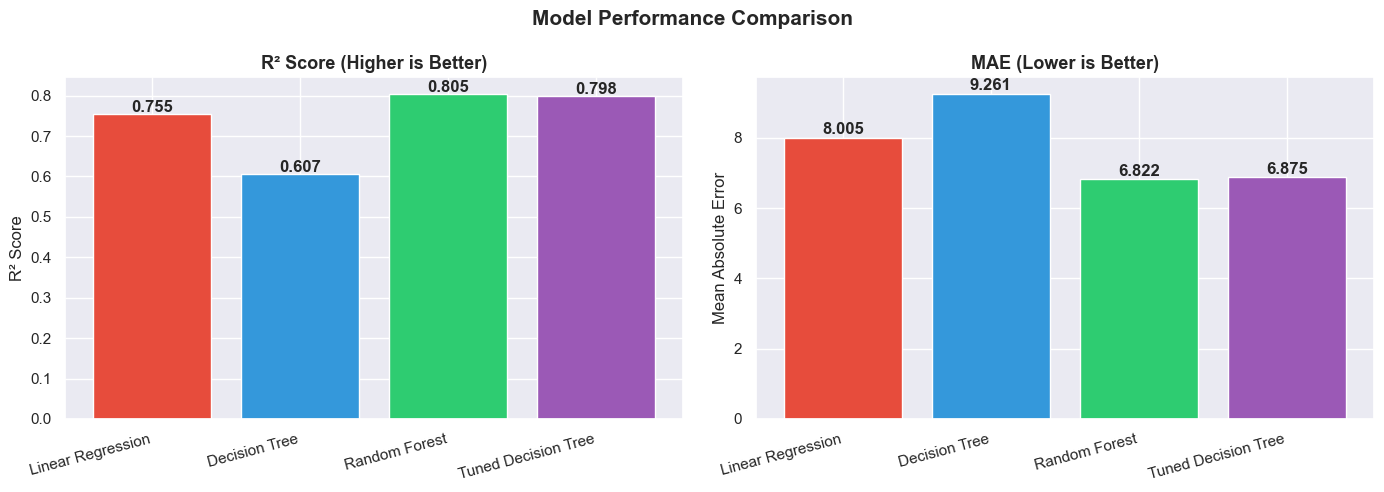

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

# R² Score
bars1 = axes[0].bar(models_list, results_df['R2 Score'], color=colors)
axes[0].set_title('R² Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_xticklabels(models_list, rotation=15, ha='right')
for bar, val in zip(bars1, results_df['R2 Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 str(val), ha='center', fontweight='bold')

# MAE
bars2 = axes[1].bar(models_list, results_df['MAE'], color=colors)
axes[1].set_title('MAE (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_xticklabels(models_list, rotation=15, ha='right')
for bar, val in zip(bars2, results_df['MAE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 13: Feature Importance (Random Forest)
### Which audio features matter the most for predicting popularity?
Random Forest gives us a **feature importance score** — how much each feature contributed to reducing prediction error across all trees.

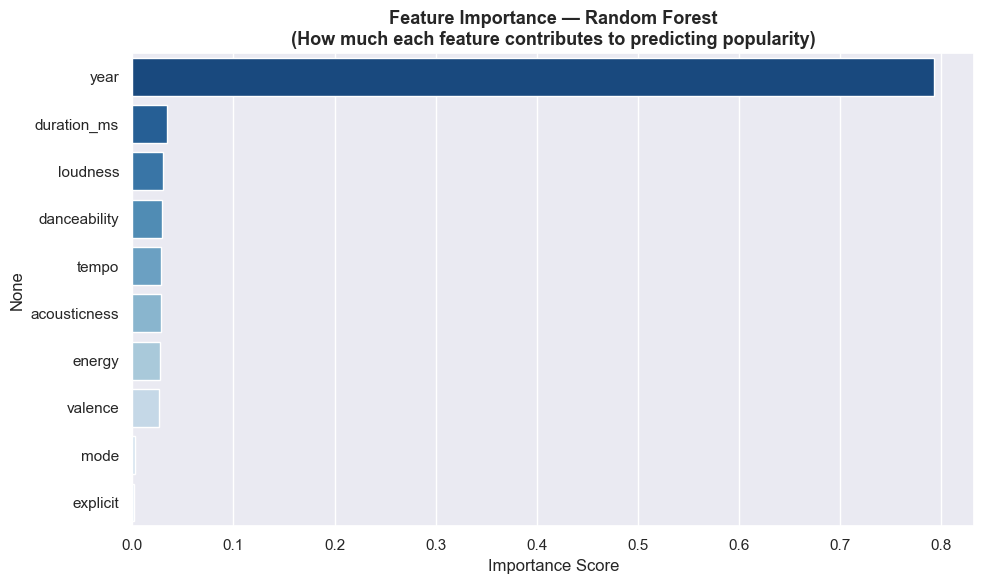

Top 3 most important features:
  1. year: 0.7927
  2. duration_ms: 0.0341
  3. loudness: 0.0298


In [23]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title('Feature Importance — Random Forest\n(How much each feature contributes to predicting popularity)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 3 most important features:')
for i, (feat, score) in enumerate(importances.head(3).items(), 1):
    print(f'  {i}. {feat}: {score:.4f}')

**Key Finding:** `year` is the most important feature for predicting popularity — recent songs tend to score higher on Spotify. Among pure audio features, `duration_ms`, `loudness`, and `energy` are the most influential.

## Step 14: Actual vs Predicted Plot
A scatter plot comparing what the model predicted vs what actually happened.  
Points closer to the **red diagonal line** = better predictions.

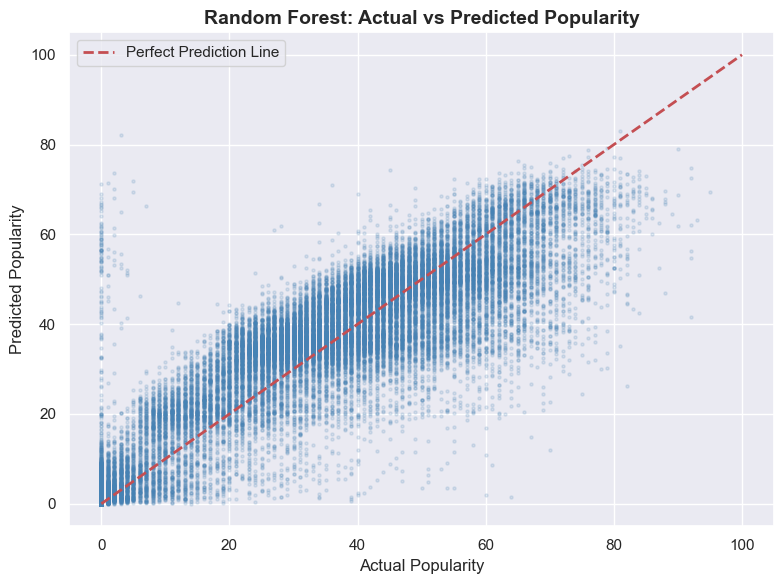

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.15, color='steelblue', s=5)
plt.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Popularity', fontsize=12)
plt.ylabel('Predicted Popularity', fontsize=12)
plt.title('Random Forest: Actual vs Predicted Popularity', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Step 15: Final Summary & Conclusions

### What We Discovered

| Finding | Insight |
|---|---|
| Energy has increased over decades | Modern music is louder and more intense |
| Acousticness has declined sharply | Electronic production has replaced acoustic instruments |
| Danceability has increased | Pop and hip-hop have made music more beat-driven |
| Year is the #1 predictor of popularity | Spotify's recency bias strongly favors new songs |
| Random Forest is the best model | Ensemble models handle complex non-linear relationships better |

### Model Performance Summary
- **Linear Regression** — weakest performer; popularity is not a linear function of audio features
- **Decision Tree (untuned)** — overfits on training data, poor test performance
- **Decision Tree (tuned)** — GridSearchCV significantly improves generalization
- **Random Forest** — best overall model, most robust to noise and overfitting

### Why is R² not very high?
Spotify popularity depends on many factors **beyond audio features** — marketing, playlist placement, social media virality, and release timing. Audio features alone explain only part of the story. This is an honest and realistic finding, not a failure of the analysis.

### Future Scope
- Add genre data to improve model accuracy
- Try XGBoost or Gradient Boosting models
- Analyze seasonal trends in music releases
- Perform NLP on song lyrics for sentiment analysis